delay_line_sim_with_aligner

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Function to calculate the endpoints of a mirror given center, length, and angle
def calculate_mirror_endpoints(center, length, angle):
    half_length = length / 2
    angle_rad = np.radians(angle)
    start = (
        center[0] - half_length * np.cos(angle_rad),
        center[1] - half_length * np.sin(angle_rad),
    )
    end = (
        center[0] + half_length * np.cos(angle_rad),
        center[1] + half_length * np.sin(angle_rad),
    )
    return start, end

# Function to find the intersection of two lines
def find_intersection(p1, p2, p3, p4):
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    x4, y4 = p4
    A1, B1, C1 = y2 - y1, x1 - x2, x1 * y2 - y1 * x2
    A2, B2, C2 = y4 - y3, x3 - x4, x3 * y4 - y3 * x4
    det = A1 * B2 - A2 * B1
    if det == 0:
        return None  # Lines are parallel
    x = (B2 * C1 - B1 * C2) / det
    y = (A1 * C2 - A2 * C1) / det
    # Check if the intersection is within both line segments
    if (min(x1, x2) <= x <= max(x1, x2) and min(y1, y2) <= y <= max(y1, y2) and
        min(x3, x4) <= x <= max(x3, x4) and min(y3, y4) <= y <= max(y3, y4)):
        return (x, y)
    return None

# Function to calculate the reflection of a laser beam
def reflect_laser(laser_start, laser_angle, mirrors, last_mirror):
    laser_angle_rad = np.radians(laser_angle)
    laser_far_end = (
        laser_start[0] + np.cos(laser_angle_rad) * 1000,
        laser_start[1] + np.sin(laser_angle_rad) * 1000,
    )
    
    closest_intersection = None
    closest_mirror = None
    min_distance = float('inf')

    # Find the closest intersection, ignoring the last mirror hit
    for mirror in mirrors:
        if mirror == last_mirror:
            continue
        intersection = find_intersection(laser_start, laser_far_end, mirror[0], mirror[1])
        if intersection is not None:
            distance = np.linalg.norm(np.array(intersection) - np.array(laser_start))
            if distance < min_distance:
                min_distance = distance
                closest_intersection = intersection
                closest_mirror = mirror

    if closest_intersection is None:
        return None, None, None  # No reflection
    
    # Reflection calculation
    mirror_start, mirror_end = closest_mirror
    mirror_vector = np.array([mirror_end[0] - mirror_start[0], mirror_end[1] - mirror_start[1]])
    mirror_length = np.linalg.norm(mirror_vector)
    mirror_unit_vector = mirror_vector / mirror_length
    normal_vector = np.array([-mirror_unit_vector[1], mirror_unit_vector[0]])
    incident_vector = np.array([closest_intersection[0] - laser_start[0], closest_intersection[1] - laser_start[1]])
    reflection_vector = (
        incident_vector - 2 * np.dot(incident_vector, normal_vector) * normal_vector
    )
    reflected_end = (
        closest_intersection[0] + reflection_vector[0],
        closest_intersection[1] + reflection_vector[1],
    )
    return closest_intersection, reflected_end, closest_mirror

In [4]:
# Function to calculate distance between two points
def calculate_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)

# Simulate laser reflections with length calculation
def simulate_laser_with_length(laser_start, laser_angle, mirrors, max_reflections=36):
    current_position = laser_start
    current_angle = laser_angle
    last_mirror = None
    laser_path = [laser_start]  # Track laser path

    for _ in range(max_reflections):
        intersection, reflected_end, hit_mirror = reflect_laser(current_position, current_angle, mirrors, last_mirror)
        if intersection is None:
            # No more intersections; add final endpoint and break
            laser_far_end = (
                current_position[0] + np.cos(np.radians(current_angle)) * 1000,
                current_position[1] + np.sin(np.radians(current_angle)) * 1000,
            )
            laser_path.append(laser_far_end)
            break

        # Update the path and continue simulation
        laser_path.append(intersection)
        current_position = intersection
        current_angle = np.degrees(np.arctan2(
            reflected_end[1] - intersection[1],
            reflected_end[0] - intersection[0],
        ))
        last_mirror = hit_mirror

    # Calculate total laser length
    total_length = sum(calculate_distance(laser_path[i], laser_path[i + 1]) for i in range(len(laser_path) - 2))
    return laser_path, total_length

def extend_line(p1, p2):
    # Calculate the length of the line
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    # Extend the line in both directions
    new_p1 = (p1[0] - 0.73*dx, p1[1] - 0.73*dy)  # Extend p1 backwards
    new_p2 = (p2[0] + 0.73*dx, p2[1] + 0.73*dy)  # Extend p2 forwards
    return new_p1, new_p2

def create_orthogonal_line_at_endpoint(endpoint, other_endpoint, length=44):
    """Create an orthogonal line of the specified length at a given endpoint."""
    # Calculate the direction vector of the original line
    dx = other_endpoint[0] - endpoint[0]
    dy = other_endpoint[1] - endpoint[1]
    
    # Get orthogonal direction
    orthogonal_dx = -dy
    orthogonal_dy = dx
    magnitude = np.sqrt(orthogonal_dx**2 + orthogonal_dy**2)
    unit_dx = orthogonal_dx / magnitude
    unit_dy = orthogonal_dy / magnitude

    # Compute the two endpoints of the orthogonal line
    ortho_p1 = (endpoint[0] + unit_dx * length, endpoint[1] + unit_dy * length)
    ortho_p2 = (endpoint[0] - unit_dx * length, endpoint[1] - unit_dy * length)
    return ortho_p1, ortho_p2

def select_furthest_orthogonal_line(endpoint, ortho_p1, ortho_p2, reference_x=100):
    """Select the orthogonal line endpoint furthest away from reference_x."""
    # Calculate distances from reference_x for each orthogonal endpoint
    dist_ortho_p1 = abs(ortho_p1[0] - reference_x)
    dist_ortho_p2 = abs(ortho_p2[0] - reference_x)
    
    # Return the endpoint further from reference_x
    if dist_ortho_p1 > dist_ortho_p2:
        return (endpoint, ortho_p1)
    else:
        return (endpoint, ortho_p2)

def process_mirrors(mirrors):
    doubled_lines = []
    orthogonal_lines = []
    
    for p1, p2 in mirrors:
        # Double the length of the original line
        extended_p1, extended_p2 = extend_line(p1, p2)
        doubled_lines.append((extended_p1, extended_p2))

        # Create orthogonal lines at the endpoints of the doubled line
        ortho_p1_a, ortho_p1_b = create_orthogonal_line_at_endpoint(extended_p1, extended_p2)
        ortho_p2_a, ortho_p2_b = create_orthogonal_line_at_endpoint(extended_p2, extended_p1)
        
        # Select only the orthogonal line furthest from x=100
        orthogonal_lines.append(select_furthest_orthogonal_line(extended_p1, ortho_p1_a, ortho_p1_b))
        orthogonal_lines.append(select_furthest_orthogonal_line(extended_p2, ortho_p2_a, ortho_p2_b))

    return doubled_lines, orthogonal_lines

In [5]:
# The diameter of usable mirror. Given 1 inch mirror: 25.4mm. Clear aperture from spec sheet: 22.9mm.
# 3mm diameter beam. 22.9 - (3/2) = 21.4 mm
mirror_lengths = [21.4, 21.4, 21.4, 21.4]

# Set up the laser
laser_start = (0, 100)
laser_angle = 0  # Initial laser angle in degrees

In [77]:
#Quad Cell Locations
qc_1 = np.array([-100, 137])
qc_2 = np.array([-300, 190])

In [78]:
def execution(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    mirrors = []

    # MIRROR CONFIGURATION
    mirror_centers = [(m1cx, m1cy), (m2cx, m2cy), (m3cx, m3cy), (m4cx, m4cy)]
    mirror_angles = [m1a, m2a, m3a, m4a] #in degrees

    for center, length, angle in zip(mirror_centers, mirror_lengths, mirror_angles):
        mirrors.append(calculate_mirror_endpoints(center, length, angle))

    # Initialize plot
    plt.figure(figsize=(12, 10))
    plt.scatter(*laser_start, color='red', label="Laser Source", linewidth=1)

    #Piezo mount outline visualizer
    doubled_lines, orthogonal_lines = process_mirrors(mirrors)

    # Draw the mirrors
    for i, mirror in enumerate(mirrors):
        plt.plot([mirror[0][0], mirror[1][0]], [mirror[0][1], mirror[1][1]], color = 'black', linewidth=3)

    #Draw piezo mirror mounts outline for fitting purposes
    for i, mirror in enumerate(doubled_lines):
        plt.plot([mirror[0][0], mirror[1][0]], [mirror[0][1], mirror[1][1]], linewidth=1, color = 'black')

    for i, mirror in enumerate(orthogonal_lines):
        plt.plot([mirror[0][0], mirror[1][0]], [mirror[0][1], mirror[1][1]], linewidth=1, color = 'black')

    # Simulate laser reflections
    max_reflections = 36
    current_position = laser_start
    current_angle = laser_angle
    last_mirror = None
    reflection_count = 0

    for i in range(max_reflections):
        intersection, reflected_end, hit_mirror = reflect_laser(current_position, current_angle, mirrors, last_mirror)
        if intersection is None:
            # No more intersections
            plt.plot(
                [current_position[0], current_position[0] + np.cos(np.radians(current_angle)) * 1000],
                [current_position[1], current_position[1] + np.sin(np.radians(current_angle)) * 1000],
                'g--'
            )
            break

        # Draw the laser and reflection
        plt.plot([current_position[0], intersection[0]], [current_position[1], intersection[1]], 'r-', linewidth =1)
        #plt.plot([intersection[0], reflected_end[0]], [intersection[1], reflected_end[1]], 'g-')
        #plt.scatter(*intersection, color='orange', label=f"Intersection {i+1}")
    
        # Update for next reflection
        current_position = intersection
        current_angle = np.degrees(np.arctan2(
            reflected_end[1] - intersection[1],
            reflected_end[0] - intersection[0],
        ))
        last_mirror = hit_mirror
        reflection_count += 1

    laser_path, total_length = simulate_laser_with_length(laser_start, laser_angle, mirrors)

    #Indicate where to cut off laser distance calculation (x=?)
    a=laser_path[-2]
    b=laser_path[-1]
    x=0
    slope = (b[1] - a[1]) / (b[0] - a[0])
    y = a[1] + slope * (x - a[0])
    x_point = (x, y)
    distance = np.sqrt((x_point[0] - a[0])**2 + (x_point[1] - a[1])**2)

    #Identify if the exiting beam gets clipped with M4
    a = np.array([a[0], a[1]])
    b = np.array([b[0], b[1]])
    m = np.array([m4cx, m4cy])
    v = b - a
    d = np.array([np.cos(np.deg2rad(m4a)), np.sin(np.deg2rad(m4a))])
    A = np.column_stack((v, -d))
    t, s = np.linalg.solve(A, m - a)
    p = a + t * v if 0 <= t <= 1 else None
    dist = np.linalg.norm(p - m)
    if dist >= 14.3: # Mirror diameter = 25.4mm. laser beam diameter = 3mm. (25.4/2) + (3/2) + 0.1(<- additional edge of mirror error)
        print("NOT CLIPPED, room to spare: ", dist-14.3, "mm")
    else:
        print("CLIPPED, ", dist-14.3, 'mm too much')

    print("Laser Path:", laser_path)
    print("Total Laser Length:", total_length+distance, "mm")
    print("Total Number of Reflection (N_R) = ", reflection_count)

    # Finalize plot
    plt.xlim(-310, 250)
    plt.ylim(-10, 210)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title("Laser Reflection with Multiple Mirrors")
    plt.xlabel("X (mm)")
    plt.ylabel("Y (mm)")
    plt.grid(True, linewidth=0.3)
    plt.plot([qc_1[0],qc_1[0]],[qc_1[1] - 2, qc_1[1] + 2], linewidth=4, label='QC1') # Quadcell Detector 1
    plt.plot([qc_2[0],qc_2[0]],[qc_2[1] - 2, qc_2[1] + 2], linewidth=4, label='QC2') # Quadcell Detector 2
    plt.legend(prop={'size': 8})
    plt.show()

NOT CLIPPED, room to spare:  2.0271582182511843 mm
Laser Path: [(0, 100), (np.float64(161.06745018261216), np.float64(100.0)), (np.float64(21.04006370830523), np.float64(66.31001585761199)), (np.float64(179.38197375018368), np.float64(66.64717406340576)), (np.float64(38.55990398115128), np.float64(107.78374493922543)), (np.float64(160.51747214101744), np.float64(104.63703361054235)), (np.float64(20.931230284415907), np.float64(67.21934546906546)), (np.float64(178.9321890271604), np.float64(63.479291455115856)), (np.float64(-787.8644440589283), np.float64(319.02629349858125))]
Total Laser Length: 1219.7754881851379 mm
Total Number of Reflection (N_R) =  7


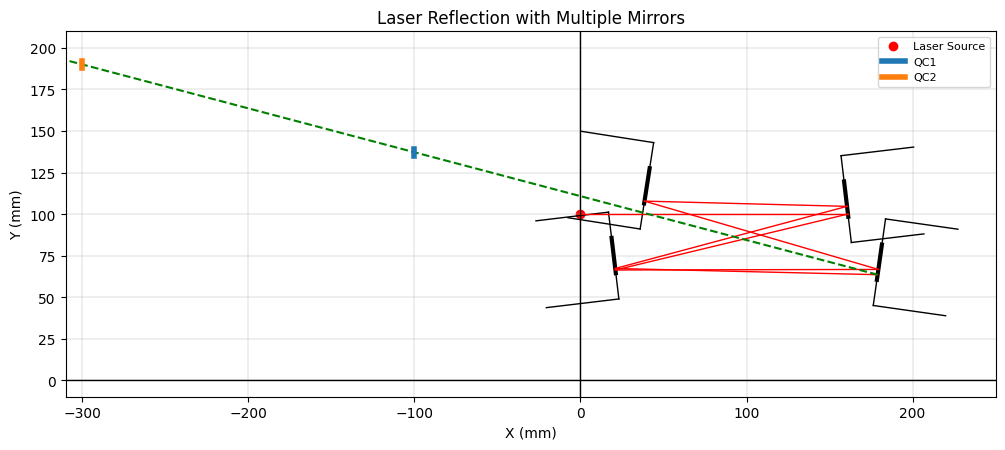

In [79]:
execution(160, 109, #M1, (x,y)
          20, 75, #M2, (x,y)
          180, 71, #M3, (x,y)
          40, 117, #M4, (x,y)
          96.764, 96.825, 81.919, 81.119) # Angle from positive x-axis (M1, M2, M3, M4)

In [ ]:

def execution_identifier(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    mirrors = []

    # MIRROR CONFIGURATION
    mirror_centers = [(m1cx, m1cy), (m2cx, m2cy), (m3cx, m3cy), (m4cx, m4cy)]
    mirror_angles = [m1a, m2a, m3a, m4a] #in degrees

    for center, length, angle in zip(mirror_centers, mirror_lengths, mirror_angles):
        mirrors.append(calculate_mirror_endpoints(center, length, angle))

    #Piezo mount outline visualizer
    doubled_lines, orthogonal_lines = process_mirrors(mirrors)

    # Simulate laser reflections
    max_reflections = 36
    current_position = laser_start
    current_angle = laser_angle
    last_mirror = None

    laser_path, total_length = simulate_laser_with_length(laser_start, laser_angle, mirrors)

    #Indicate where to cut off laser distance calculation (x=?)
    a=laser_path[-2]
    b=laser_path[-1]
    x=0
    slope = (b[1] - a[1]) / (b[0] - a[0])
    y = a[1] + slope * (x - a[0])
    x_point = (x, y)
    distance = np.sqrt((x_point[0] - a[0])**2 + (x_point[1] - a[1])**2)

    last_two = laser_path[-2:]
    exit_slope = (last_two[1][1]-last_two[0][1])/(last_two[1][0]-last_two[0][0])
    y_int=last_two[1][1]-exit_slope*last_two[1][0]
    y100=exit_slope*-100+y_int
    return exit_slope, total_length+distance, y100

In [ ]:

execution_identifier(160, 109, #M1, (x,y)
                     20, 75, #M2, (x,y)
                     180, 71, #M3, (x,y)
                     40, 117, #M4, (x,y)
                     96.764, 96.825, 81.919, 81.119) # Angle from positive x-axis (M1, M2, M3, M4)

(np.float64(-0.2643234298693613),
 np.float64(1219.7754881851379),
 np.float64(137.20760435974393))

In [ ]:
#Old function for finding solution of J@x = b
def general_solution_with_scalar(J, b, tol=1e-10):
    """
    Solve J @ x = b and return (x0, v) s.t. all solutions are:
        x = x0 + a * v,  for any scalar a.
    If nullity = 0, v is None and the solution is unique (or least-squares if inconsistent).
    """
    J = np.asarray(J, dtype=float)
    b = np.asarray(b, dtype=float)

    # SVD: J = U[:, :r] diag(s[:r]) Vh[:r, :]
    U, s, Vh = np.linalg.svd(J, full_matrices=True)
    # rank with a robust threshold
    thresh = tol * max(J.shape) * (s[0] if s.size else 0.0)
    r = int(np.sum(s > thresh))

    # Minimum-norm particular solution using sliced SVD pieces
    # x0 = V[:, :r] @ diag(1/s[:r]) @ U[:, :r]^T @ b
    x0 = Vh.T[:, :r] @ ((U.T[:r, :] @ b) / s[:r])

    # Null-space vector: first column of V corresponding to zero singular values
    v = None
    if Vh.shape[0] > r:
        v = Vh.T[:, r]
        nrm = np.linalg.norm(v)
        if nrm > 0:
            v = v / nrm

    # (Optional) residual check; for consistent systems this is ~0
    resid = np.linalg.norm(J @ x0 - b)

    return x0, v, resid

In [ ]:
#Calculates beta for qc_1 (qc_1 initialized earlier)

def calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    res = execution_identifier(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a)
    y100 = res[2]
    qc_loc1 = np.array([-100, 137])
    beta1 = y100 - qc_1[1]
    return beta1

In [118]:
def calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    res = execution_identifier(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a)
    y300 = res[2] - res[0] * 200
    qc_loc2 = np.array([-300, 190])
    beta2 = y300 - qc_2[1]
    return beta2

In [119]:
def calc_B(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    B = np.zeros([2])
    B[0] = calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a)
    B[1] = calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a)
    return B

In [120]:
def calc_jacobian(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a, m1da, m2da, m3da):
    J = np.zeros([2,3])
    J[0,0] = (calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a + m1da, m2a, m3a, m4a) - calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a - m1da, m2a, m3a, m4a))/(2*m1da)
    J[0,1] = (calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a + m2da, m3a, m4a) - calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a - m2da, m3a, m4a))/(2*m2da)
    J[0,2] = (calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a + m3da, m4a) - calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a - m3da, m4a))/(2*m3da)
    J[1,0] = (calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a + m1da, m2a, m3a, m4a) - calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a - m1da, m2a, m3a, m4a))/(2*m1da)
    J[1,1] = (calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a + m2da, m3a, m4a) - calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a - m2da, m3a, m4a))/(2*m2da)
    J[1,2] = (calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a + m3da, m4a) - calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a - m3da, m4a))/(2*m3da)
    return J

    

In [121]:
#initialize mirror positions and angles

m1cx = 160
m1cy = 109 #M1, (x,y)
m2cx = 20
m2cy = 75 #M2, (x,y)
m3cx = 180
m3cy = 71 #M3, (x,y)
m4cx = 40
m4cy = 117 #M4, (x,y)
m1a0 = 96.74
m2a0 = 96.8
m3a0 = 81.91
m4a0 = 82.119



B(alpha0) = [-18.45251045 -75.20890061]
Converged: True iters: 6 
reason: ||B|| <= tol_beta
Final Angles [m1, m2, m3, m4] = [96.61461296 95.90116373 81.86543724 82.119     ]
Final β vector = [-1.98951966e-13 -3.41060513e-13]

NOT CLIPPED, room to spare:  2.352209651800294 mm
Laser Path: [(0, 100), (np.float64(161.04366172596445), np.float64(100.0)), (np.float64(20.823151703811654), np.float64(67.03610759293737)), (np.float64(178.87069602819844), np.float64(63.099265552527456)), (np.float64(-787.7641661896234), np.float64(319.2575040402495))]
Total Laser Length: 648.2280521010674 mm
Total Number of Reflection (N_R) =  3


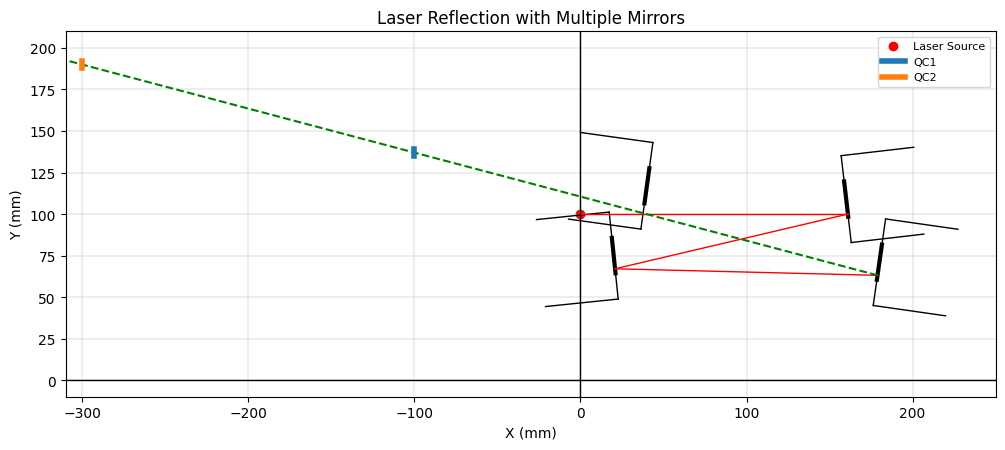

In [130]:
#import angle alignment functions from python classes (must download laser_align.py)

from laser_align import align_mirrors, AlignConfig

# m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy
# m1a0, m2a0, m3a0, m4a0

geom = dict(
    m1cx=m1cx, m1cy=m1cy,
    m2cx=m2cx, m2cy=m2cy,
    m3cx=m3cx, m3cy=m3cy,
    m4cx=m4cx, m4cy=m4cy,
)

# FIXED 4th-mirror angle:
m4a_fixed = float(m4a0)

# finite-difference steps (match your angle units: if degrees, use e.g. 1e-4)
m1da = m2da = m3da = 1e-4

def B_fn(alpha: np.ndarray) -> np.ndarray:
    m1a, m2a, m3a = map(float, alpha)
    return np.asarray(calc_B(
        geom['m1cx'], geom['m1cy'],
        geom['m2cx'], geom['m2cy'],
        geom['m3cx'], geom['m3cy'],
        geom['m4cx'], geom['m4cy'],
        m1a, m2a, m3a, m4a_fixed
    )).reshape(-1)

def J_fn(alpha: np.ndarray) -> np.ndarray:
    m1a, m2a, m3a = map(float, alpha)
    J = calc_jacobian(
        geom['m1cx'], geom['m1cy'],
        geom['m2cx'], geom['m2cy'],
        geom['m3cx'], geom['m3cy'],
        geom['m4cx'], geom['m4cy'],
        m1a, m2a, m3a, m4a_fixed,
        m1da, m2da, m3da
    )
    return np.asarray(J, float)   # already divided by 2*da in your code

# start with mirrors 1–3; mirror 4 is fixed at m4a_fixed
alpha0 = np.array([m1a0, m2a0, m3a0], float)

# original beta
print("B(alpha0) =", B_fn(alpha0))           # -> length-2

cfg = AlignConfig(damping=1e-3, tol_beta=1e-10, max_iters=100, verbose=True)
res = align_mirrors(J_fn, B_fn, alpha0, cfg)

final_angles = np.array([res.alpha[0], res.alpha[1], res.alpha[2], m4a_fixed])
final_B = B_fn(res.alpha)
print("Converged:", res.converged, "iters:", res.iters, "\nreason:", res.reason)
print("Final Angles [m1, m2, m3, m4] =", final_angles)
print(f"Final β vector = {final_B}\n")

#To see plot, clipping, reflections, etc after alignment
execution(160, 109, #M1, (x,y)
          20, 75, #M2, (x,y)
          180, 71, #M3, (x,y)
          40, 117, #M4, (x,y)
          final_angles[0], final_angles[1], final_angles[2], final_angles[3]) # Angle from positive x-axis (M1, M2, M3, M4)

In [114]:
# === Report angle changes ===

alpha_init = alpha0.astype(float)
alpha_final = res.alpha.astype(float)
delta_alpha = (alpha_final - alpha_init)

print(f"\nFinal angles:")
print(f"  m1: {alpha_final[0]*to_user:.9g} {unit_name}")
print(f"  m2: {alpha_final[1]*to_user:.9g} {unit_name}")
print(f"  m3: {alpha_final[2]*to_user:.9g} {unit_name}")
print(f"  m4 (fixed): {m4a_fixed*to_user:.9g} {unit_name}")

print(f"\nChange in angles (Δ = final − initial):")
print(f"  Δm1: {(delta_alpha[0])*to_user:+.9g} {unit_name}")
print(f"  Δm2: {(delta_alpha[1])*to_user:+.9g} {unit_name}")
print(f"  Δm3: {(delta_alpha[2])*to_user:+.9g} {unit_name}")
print(f"  Δm4: {0.0:+.9g} {unit_name}  # fixed")

# Also show beta norm improvement
import numpy as np
print(f"\n‖B(init)‖ = {np.linalg.norm(B_fn(alpha_init)):.6e}")
print(f"‖B(final)‖ = {np.linalg.norm(B_fn(alpha_final)):.6e}")

# res.history["alpha"] holds the alpha after each iteration (including initial in index 0)
alphas = np.array(res.history["alpha"])  # shape: (k+1, 3)
deltas_iter = np.diff(alphas, axis=0)    # shape: (k, 3)
for k, d in enumerate(deltas_iter, start=1):
    print(f"iter {k:02d} Δα = [{d[0]*to_user:+.3g}, {d[1]*to_user:+.3g}, {d[2]*to_user:+.3g}] {unit_name}")



Final angles:
  m1: 96.614613 deg
  m2: 95.9011637 deg
  m3: 81.8654372 deg
  m4 (fixed): 82.119 deg

Change in angles (Δ = final − initial):
  Δm1: -0.125387038 deg
  Δm2: -0.898836272 deg
  Δm3: -0.0445627632 deg
  Δm4: +0 deg  # fixed

‖B(init)‖ = 7.743949e+01
‖B(final)‖ = 3.948470e-13
iter 01 Δα = [-0.168, -0.0349, +0.26] deg
iter 02 Δα = [+0.000193, -0.298, +0.331] deg
iter 03 Δα = [+0.0423, -0.00041, -0.0461] deg
iter 04 Δα = [+0, -0.565, -0.589] deg
iter 05 Δα = [+0, +0.000198, +0.000203] deg
iter 06 Δα = [+0, +1.19e-10, +1.62e-10] deg
